In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to LOBSTER data
lobster_path = "D:/MSc/MLP/Sem 2/Project/LOBSTER Data/extracted/"

Using device: cuda


In [2]:
def load_lobster_orderbook(filepath):
    """Load LOBSTER orderbook and convert to FI-2010 format"""
    df = pd.read_csv(filepath, header=None)
    
    # LOBSTER: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s, ...
    # FI-2010: ask1_p, ask1_s, ask2_p, ask2_s, ..., ask10_p, ask10_s, bid1_p, bid1_s, ..., bid10_p, bid10_s
    
    n_levels = 10
    ask_cols = []
    bid_cols = []
    
    for i in range(n_levels):
        ask_cols.extend([i*4, i*4+1])      # ask_price, ask_size
        bid_cols.extend([i*4+2, i*4+3])    # bid_price, bid_size
    
    # Reorder: all asks first, then all bids
    reordered = df.iloc[:, ask_cols + bid_cols].values
    
    return reordered

# Load all stocks
stocks = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
lobster_data = {}

for stock in stocks:
    filepath = f"{lobster_path}{stock}_2012-06-21_34200000_57600000_orderbook_10.csv"
    lobster_data[stock] = load_lobster_orderbook(filepath)
    print(f"{stock}: {lobster_data[stock].shape}")

AAPL: (400391, 40)
AMZN: (269748, 40)
GOOG: (147916, 40)
INTC: (624040, 40)
MSFT: (668765, 40)


In [3]:
def normalize_lobster(data):
    """Z-score normalization per feature"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1  # avoid division by zero
    return (data - mean) / std

def create_labels(data, k=10):
    """Create mid-price movement labels (same as FI-2010)"""
    # Mid-price = (best_ask + best_bid) / 2
    # In FI-2010 format: col 0 = ask1_price, col 20 = bid1_price
    mid_price = (data[:, 0] + data[:, 20]) / 2
    
    labels = np.zeros(len(mid_price))
    
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        
        pct_change = (future_avg - current) / current
        
        # Threshold similar to FI-2010 (0.002 = 0.2%)
        if pct_change > 0.0002:
            labels[i] = 2  # up
        elif pct_change < -0.0002:
            labels[i] = 0  # down
        else:
            labels[i] = 1  # stationary
    
    return labels.astype(int)

# Process each stock
for stock in stocks:
    lobster_data[stock] = normalize_lobster(lobster_data[stock])
    
print("Normalization complete")
print(f"Sample mean (should be ~0): {lobster_data['AAPL'].mean():.6f}")
print(f"Sample std (should be ~1): {lobster_data['AAPL'].std():.6f}")

Normalization complete
Sample mean (should be ~0): -0.000000
Sample std (should be ~1): 1.000000


In [4]:
def prepare_sequences_subset(data, labels, T=100, max_samples=50000):
    """Create sequences - subset to avoid memory issues"""
    N = min(len(data) - T - 10, max_samples)
    
    X = np.zeros((N, T, 40), dtype=np.float32)
    y = np.zeros(N, dtype=np.int64)
    
    for i in range(N):
        X[i] = data[i:i+T]
        y[i] = labels[i+T]
    
    return X, y

# Evaluate AAPL (first 50k samples)
stock = 'AAPL'
labels = create_labels(lobster_data[stock], k=10)
X_test, y_test = prepare_sequences_subset(lobster_data[stock].astype(np.float32), labels, T=100, max_samples=50000)

print(f"{stock}: {X_test.shape[0]} samples")
print(f"Label distribution: {np.bincount(y_test)}")

AAPL: 50000 samples
Label distribution: [19198 10597 20205]


In [6]:
class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception modules
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)
    
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)  
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)
        
        return forecast_y

# Load trained model
model = torch.load('jupyter_pytorch/best_val_model_pytorch', map_location=device)
model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


C:\Users\Ash\AppData\Local\Temp\ipykernel_16088\3637503823.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('jupyter_pytorch/best_val_model_pytorch', 

In [7]:
# Create dataloader
dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

# Evaluate
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Results
print(f"LOBSTER ({stock}) - FI-2010 trained model:")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Stationary', 'Up']))

LOBSTER (AAPL) - FI-2010 trained model:
Accuracy: 0.4030
              precision    recall  f1-score   support

        Down       0.38      0.24      0.29     19198
  Stationary       0.32      0.00      0.01     10597
          Up       0.41      0.77      0.53     20205

    accuracy                           0.40     50000
   macro avg       0.37      0.34      0.28     50000
weighted avg       0.38      0.40      0.33     50000



In [8]:
results = {'AAPL': {'acc': 0.4030, 'f1': 0.28}}

for stock in ['AMZN', 'GOOG', 'INTC', 'MSFT']:
    labels = create_labels(lobster_data[stock], k=10)
    X_test, y_test = prepare_sequences_subset(lobster_data[stock].astype(np.float32), labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    results[stock] = {'acc': acc, 'f1': f1}
    print(f"{stock}: Accuracy={acc:.4f}, F1={f1:.4f}")

print("\n--- Summary ---")
for stock, res in results.items():
    print(f"{stock}: Acc={res['acc']:.2%}, F1={res['f1']:.2%}")

AMZN: Accuracy=0.2945, F1=0.2380
GOOG: Accuracy=0.3248, F1=0.2543
INTC: Accuracy=0.2768, F1=0.2015
MSFT: Accuracy=0.2979, F1=0.2070

--- Summary ---
AAPL: Acc=40.30%, F1=28.00%
AMZN: Acc=29.45%, F1=23.80%
GOOG: Acc=32.48%, F1=25.43%
INTC: Acc=27.68%, F1=20.15%
MSFT: Acc=29.79%, F1=20.70%


In [9]:
# Load raw FI-2010 data (before normalization)
fi_train = np.loadtxt('data/Train_Dst_NoAuction_DecPre_CF_7.txt')
fi_test1 = np.loadtxt('data/Test_Dst_NoAuction_DecPre_CF_7.txt')

# FI-2010 format: rows are features, columns are time -> transpose
fi_data = np.hstack([fi_train, fi_test1]).T
fi_lob = fi_data[:, :40]  # First 40 columns are LOB data

print(f"FI-2010 shape: {fi_lob.shape}")

# Reload raw LOBSTER (before normalization)
lobster_raw = {}
for stock in stocks:
    filepath = f"{lobster_path}{stock}_2012-06-21_34200000_57600000_orderbook_10.csv"
    lobster_raw[stock] = load_lobster_orderbook(filepath)
    
print(f"LOBSTER AAPL shape: {lobster_raw['AAPL'].shape}")

FI-2010 shape: (310228, 40)
LOBSTER AAPL shape: (400391, 40)


c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


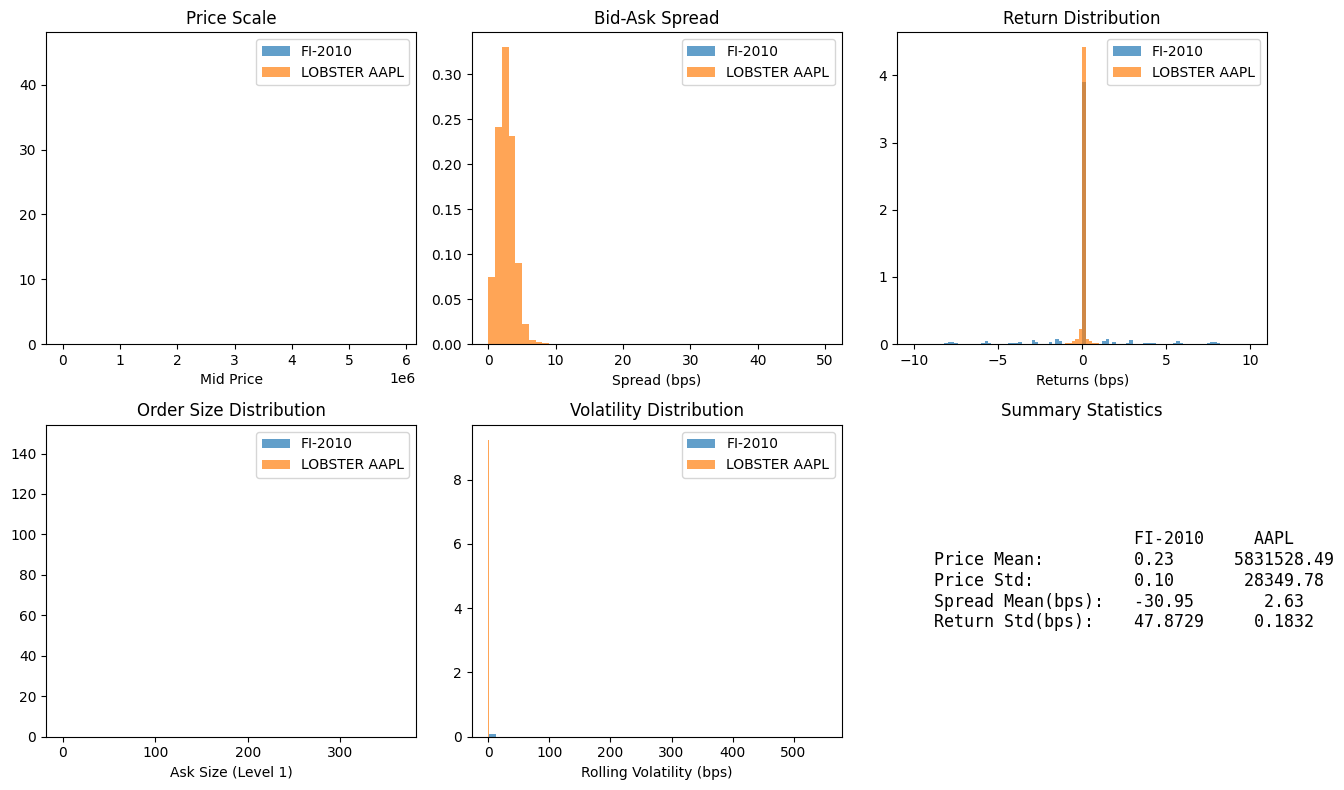

Saved: distribution_comparison.png


In [10]:
import matplotlib.pyplot as plt

# Calculate key metrics for both datasets
def calc_metrics(data):
    """Calculate LOB metrics. Format: ask prices (cols 0,2,4..18), ask sizes (1,3,5..19), 
    bid prices (20,22,24..38), bid sizes (21,23,25..39)"""
    ask1_price = data[:, 0]
    bid1_price = data[:, 20]
    ask1_size = data[:, 1]
    bid1_size = data[:, 21]
    
    mid_price = (ask1_price + bid1_price) / 2
    spread = ask1_price - bid1_price
    spread_bps = (spread / mid_price) * 10000  # basis points
    
    # Returns (mid-price changes)
    returns = np.diff(mid_price) / mid_price[:-1]
    
    return {
        'mid_price': mid_price,
        'spread_bps': spread_bps,
        'returns': returns,
        'ask1_size': ask1_size,
        'bid1_size': bid1_size
    }

fi_metrics = calc_metrics(fi_lob)
aapl_metrics = calc_metrics(lobster_raw['AAPL'])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1. Mid-price scale
axes[0,0].hist(fi_metrics['mid_price'], bins=50, alpha=0.7, label='FI-2010', density=True)
axes[0,0].hist(aapl_metrics['mid_price'], bins=50, alpha=0.7, label='LOBSTER AAPL', density=True)
axes[0,0].set_xlabel('Mid Price')
axes[0,0].set_title('Price Scale')
axes[0,0].legend()

# 2. Spread (basis points)
axes[0,1].hist(fi_metrics['spread_bps'], bins=50, alpha=0.7, label='FI-2010', density=True, range=(0, 50))
axes[0,1].hist(aapl_metrics['spread_bps'], bins=50, alpha=0.7, label='LOBSTER AAPL', density=True, range=(0, 50))
axes[0,1].set_xlabel('Spread (bps)')
axes[0,1].set_title('Bid-Ask Spread')
axes[0,1].legend()

# 3. Returns distribution
axes[0,2].hist(fi_metrics['returns']*10000, bins=100, alpha=0.7, label='FI-2010', density=True, range=(-10, 10))
axes[0,2].hist(aapl_metrics['returns']*10000, bins=100, alpha=0.7, label='LOBSTER AAPL', density=True, range=(-10, 10))
axes[0,2].set_xlabel('Returns (bps)')
axes[0,2].set_title('Return Distribution')
axes[0,2].legend()

# 4. Ask size
axes[1,0].hist(fi_metrics['ask1_size'], bins=50, alpha=0.7, label='FI-2010', density=True, range=(0, np.percentile(fi_metrics['ask1_size'], 95)))
axes[1,0].hist(aapl_metrics['ask1_size'], bins=50, alpha=0.7, label='LOBSTER AAPL', density=True, range=(0, np.percentile(aapl_metrics['ask1_size'], 95)))
axes[1,0].set_xlabel('Ask Size (Level 1)')
axes[1,0].set_title('Order Size Distribution')
axes[1,0].legend()

# 5. Volatility (rolling std of returns)
window = 1000
fi_vol = pd.Series(fi_metrics['returns']).rolling(window).std() * 10000
aapl_vol = pd.Series(aapl_metrics['returns']).rolling(window).std() * 10000
axes[1,1].hist(fi_vol.dropna(), bins=50, alpha=0.7, label='FI-2010', density=True)
axes[1,1].hist(aapl_vol.dropna(), bins=50, alpha=0.7, label='LOBSTER AAPL', density=True)
axes[1,1].set_xlabel('Rolling Volatility (bps)')
axes[1,1].set_title('Volatility Distribution')
axes[1,1].legend()

# 6. Summary stats table
axes[1,2].axis('off')
stats_text = f"""
                    FI-2010     AAPL
Price Mean:         {fi_metrics['mid_price'].mean():.2f}      {aapl_metrics['mid_price'].mean():.2f}
Price Std:          {fi_metrics['mid_price'].std():.2f}       {aapl_metrics['mid_price'].std():.2f}
Spread Mean(bps):   {fi_metrics['spread_bps'].mean():.2f}       {aapl_metrics['spread_bps'].mean():.2f}
Return Std(bps):    {fi_metrics['returns'].std()*10000:.4f}     {aapl_metrics['returns'].std()*10000:.4f}
"""
axes[1,2].text(0.1, 0.5, stats_text, fontsize=12, family='monospace', verticalalignment='center')
axes[1,2].set_title('Summary Statistics')

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150)
plt.show()

print("Saved: distribution_comparison.png")

In [11]:
# Correct FI-2010 format
def calc_metrics_fi2010(data):
    """FI-2010: cols 0-9 ask prices, 10-19 ask sizes, 20-29 bid prices, 30-39 bid sizes"""
    ask1_price = data[:, 0]
    bid1_price = data[:, 20]
    ask1_size = data[:, 10]
    bid1_size = data[:, 30]
    
    mid_price = (ask1_price + bid1_price) / 2
    spread = ask1_price - bid1_price
    spread_bps = (spread / mid_price) * 10000
    returns = np.diff(mid_price) / mid_price[:-1]
    
    return {
        'mid_price': mid_price,
        'spread_bps': spread_bps,
        'returns': returns,
        'ask1_size': ask1_size,
        'bid1_size': bid1_size
    }

def calc_metrics_lobster(data):
    """LOBSTER reordered: cols 0-19 asks (p,s alternating), 20-39 bids"""
    ask1_price = data[:, 0]
    bid1_price = data[:, 20]
    ask1_size = data[:, 1]
    bid1_size = data[:, 21]
    
    mid_price = (ask1_price + bid1_price) / 2
    spread = ask1_price - bid1_price
    spread_bps = (spread / mid_price) * 10000
    returns = np.diff(mid_price) / mid_price[:-1]
    
    return {
        'mid_price': mid_price,
        'spread_bps': spread_bps,
        'returns': returns,
        'ask1_size': ask1_size,
        'bid1_size': bid1_size
    }

fi_metrics = calc_metrics_fi2010(fi_lob)
aapl_metrics = calc_metrics_lobster(lobster_raw['AAPL'])

print("=== FI-2010 ===")
print(f"Price Mean: {fi_metrics['mid_price'].mean():.4f}")
print(f"Price Std: {fi_metrics['mid_price'].std():.4f}")
print(f"Spread Mean (bps): {fi_metrics['spread_bps'].mean():.2f}")
print(f"Return Std (bps): {fi_metrics['returns'].std()*10000:.4f}")

print("\n=== LOBSTER AAPL ===")
print(f"Price Mean: {aapl_metrics['mid_price'].mean():.2f}")
print(f"Price Std: {aapl_metrics['mid_price'].std():.2f}")
print(f"Spread Mean (bps): {aapl_metrics['spread_bps'].mean():.2f}")
print(f"Return Std (bps): {aapl_metrics['returns'].std()*10000:.4f}")

=== FI-2010 ===
Price Mean: 0.2301
Price Std: 0.1016
Spread Mean (bps): -30.95
Return Std (bps): 47.8729

=== LOBSTER AAPL ===
Price Mean: 5831528.49
Price Std: 28349.78
Spread Mean (bps): 2.63
Return Std (bps): 0.1832


In [12]:
# Check first row of FI-2010 to understand format
print("FI-2010 first row (first 10 values):", fi_lob[0, :10])
print("FI-2010 first row (values 20-30):", fi_lob[0, 20:30])

# Check if asks > bids (should be true)
print(f"\nCol 0 mean: {fi_lob[:, 0].mean():.4f}")
print(f"Col 20 mean: {fi_lob[:, 20].mean():.4f}")

# Try different interpretation: maybe it's ask1, bid1, ask2, bid2...
print(f"\nAlt check - Col 0 vs Col 1:")
print(f"Col 0 mean: {fi_lob[:, 0].mean():.4f}")
print(f"Col 1 mean: {fi_lob[:, 1].mean():.4f}")

FI-2010 first row (first 10 values): [0.2615  0.00353 0.2606  0.00326 0.2618  0.002   0.2604  0.00682 0.2619
 0.00164]
FI-2010 first row (values 20-30): [0.2623  0.00837 0.2595  0.001   0.2625  0.0015  0.2593  0.00143 0.2626
 0.00787]

Col 0 mean: 0.2298
Col 20 mean: 0.2304

Alt check - Col 0 vs Col 1:
Col 0 mean: 0.2298
Col 1 mean: 0.0114


In [13]:
def load_lobster_fi2010_format(filepath):
    """Load LOBSTER and keep same format as FI-2010 (interleaved by level)"""
    df = pd.read_csv(filepath, header=None)
    # LOBSTER raw: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s, ...
    # FI-2010:     ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s, ...
    # They're the same! No reordering needed.
    return df.values

# Reload LOBSTER without reordering
lobster_raw_correct = {}
for stock in stocks:
    filepath = f"{lobster_path}{stock}_2012-06-21_34200000_57600000_orderbook_10.csv"
    lobster_raw_correct[stock] = load_lobster_fi2010_format(filepath)

# Verify format matches
print("LOBSTER AAPL first row (first 8 values):")
print(lobster_raw_correct['AAPL'][0, :8])
print("\nExpected: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s")

# Check spread is positive
ask1 = lobster_raw_correct['AAPL'][:, 0]
bid1 = lobster_raw_correct['AAPL'][:, 2]
spread = ask1 - bid1
print(f"\nSpread check: mean={spread.mean():.2f}, all positive={np.all(spread > 0)}")

LOBSTER AAPL first row (first 8 values):
[5859400     200 5853300      18 5859800     200 5853000     150]

Expected: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s

Spread check: mean=1534.89, all positive=True


In [14]:
def normalize_data(data):
    """Z-score normalization"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return (data - mean) / std

def create_labels_correct(data, k=10):
    """Labels using correct column order: col 0=ask1, col 2=bid1"""
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price))
    
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        
        if pct_change > 0.0002:
            labels[i] = 2  # up
        elif pct_change < -0.0002:
            labels[i] = 0  # down
        else:
            labels[i] = 1  # stationary
    
    return labels.astype(int)

# Process AAPL with correct format
stock = 'AAPL'
data_norm = normalize_data(lobster_raw_correct[stock].astype(np.float32))
labels = create_labels_correct(lobster_raw_correct[stock], k=10)
X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)

print(f"{stock}: {X_test.shape[0]} samples")
print(f"Label distribution: {np.bincount(y_test)}")

# Evaluate
dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(f"\nCorrected LOBSTER ({stock}):")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Stationary', 'Up']))

AAPL: 50000 samples
Label distribution: [  154 49740   106]

Corrected LOBSTER (AAPL):
Accuracy: 0.0036
              precision    recall  f1-score   support

        Down       0.00      0.49      0.01       154
  Stationary       1.00      0.00      0.00     49740
          Up       0.00      0.51      0.00       106

    accuracy                           0.00     50000
   macro avg       0.34      0.33      0.00     50000
weighted avg       0.99      0.00      0.00     50000



In [15]:
# Find threshold that gives similar label distribution to FI-2010
def get_label_distribution(data, threshold):
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price) - 10)
    
    for i in range(len(labels)):
        future_avg = np.mean(mid_price[i+1:i+11])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        
        if pct_change > threshold:
            labels[i] = 2
        elif pct_change < -threshold:
            labels[i] = 0
        else:
            labels[i] = 1
    
    counts = np.bincount(labels.astype(int), minlength=3)
    return counts / len(labels) * 100

# Test different thresholds for LOBSTER
print("LOBSTER AAPL label distribution by threshold:")
print("Threshold\tDown%\tStat%\tUp%")
for thresh in [0.0002, 0.0001, 0.00005, 0.00002, 0.00001, 0.000005]:
    dist = get_label_distribution(lobster_raw_correct['AAPL'], thresh)
    print(f"{thresh:.6f}\t{dist[0]:.1f}\t{dist[1]:.1f}\t{dist[2]:.1f}")

# FI-2010 reference
print("\nFI-2010 label distribution (threshold=0.0002):")
dist_fi = get_label_distribution(fi_lob, 0.0002)
print(f"0.000200\t{dist_fi[0]:.1f}\t{dist_fi[1]:.1f}\t{dist_fi[2]:.1f}")

LOBSTER AAPL label distribution by threshold:
Threshold	Down%	Stat%	Up%
0.000200	0.0	99.9	0.0
0.000100	0.7	98.7	0.6
0.000050	3.8	92.6	3.7
0.000020	12.8	74.6	12.6
0.000010	21.1	58.1	20.8
0.000005	28.7	43.2	28.1

FI-2010 label distribution (threshold=0.0002):
0.000200	22.3	55.0	22.8


In [16]:
def create_labels_calibrated(data, k=10, threshold=0.00001):
    """Labels with calibrated threshold for LOBSTER"""
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price))
    
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        
        if pct_change > threshold:
            labels[i] = 2
        elif pct_change < -threshold:
            labels[i] = 0
        else:
            labels[i] = 1
    
    return labels.astype(int)

# Re-evaluate with calibrated labels
stock = 'AAPL'
data_norm = normalize_data(lobster_raw_correct[stock].astype(np.float32))
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)
X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)

print(f"{stock}: {X_test.shape[0]} samples")
print(f"Label distribution: {np.bincount(y_test)}")

# Evaluate
dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(f"\nCalibrated LOBSTER ({stock}):")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Stationary', 'Up']))

AAPL: 50000 samples
Label distribution: [13669 21838 14493]

Calibrated LOBSTER (AAPL):
Accuracy: 0.2862
              precision    recall  f1-score   support

        Down       0.28      0.41      0.33     13669
  Stationary       0.62      0.00      0.00     21838
          Up       0.29      0.59      0.39     14493

    accuracy                           0.29     50000
   macro avg       0.40      0.34      0.24     50000
weighted avg       0.43      0.29      0.21     50000



In [17]:
results_calibrated = {}

for stock in stocks:
    data_norm = normalize_data(lobster_raw_correct[stock].astype(np.float32))
    labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)
    X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    results_calibrated[stock] = {'acc': acc, 'f1': f1}
    print(f"{stock}: Acc={acc:.2%}, F1={f1:.2%}, Labels={np.bincount(y_test)}")

print("\n=== Summary (Calibrated Threshold) ===")
print("Stock\t\tAccuracy\tF1")
print("-" * 35)
for stock, res in results_calibrated.items():
    print(f"{stock}\t\t{res['acc']:.2%}\t\t{res['f1']:.2%}")
avg_acc = np.mean([r['acc'] for r in results_calibrated.values()])
avg_f1 = np.mean([r['f1'] for r in results_calibrated.values()])
print("-" * 35)
print(f"Average\t\t{avg_acc:.2%}\t\t{avg_f1:.2%}")

AAPL: Acc=28.62%, F1=24.21%, Labels=[13669 21838 14493]
AMZN: Acc=23.83%, F1=21.15%, Labels=[12942 24815 12243]
GOOG: Acc=25.13%, F1=21.77%, Labels=[14364 23484 12152]
INTC: Acc=31.15%, F1=23.04%, Labels=[ 3681 42719  3600]
MSFT: Acc=30.67%, F1=22.07%, Labels=[ 3818 42492  3690]

=== Summary (Calibrated Threshold) ===
Stock		Accuracy	F1
-----------------------------------
AAPL		28.62%		24.21%
AMZN		23.83%		21.15%
GOOG		25.13%		21.77%
INTC		31.15%		23.04%
MSFT		30.67%		22.07%
-----------------------------------
Average		27.88%		22.45%


In [18]:
def normalize_zscore(data):
    """Z-score: (x - mean) / std"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return (data - mean) / std

def normalize_minmax(data):
    """Min-max: scale to [0, 1]"""
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1
    return (data - min_val) / range_val

def normalize_decimal_precision(data):
    """Decimal precision: divide by power of 10 to get small numbers"""
    # Find max value and scale down
    max_val = np.max(np.abs(data), axis=0)
    scale = 10 ** np.floor(np.log10(max_val + 1))
    return data / scale

def normalize_match_fi2010(data, fi_data):
    """Force LOBSTER to have same mean/std as FI-2010 per column"""
    fi_mean = np.mean(fi_data, axis=0)
    fi_std = np.std(fi_data, axis=0)
    
    data_mean = np.mean(data, axis=0)
    data_std = np.std(data, axis=0)
    data_std[data_std == 0] = 1
    
    # Standardize then rescale to FI-2010 statistics
    normalized = (data - data_mean) / data_std
    return normalized * fi_std + fi_mean

# Test each normalization on AAPL
stock = 'AAPL'
raw_data = lobster_raw_correct[stock].astype(np.float32)
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)

normalizations = {
    'Z-score': normalize_zscore(raw_data),
    'Min-max': normalize_minmax(raw_data),
    'Decimal': normalize_decimal_precision(raw_data),
    'Match FI-2010': normalize_match_fi2010(raw_data, fi_lob)
}

print("Testing normalizations on AAPL...\n")
norm_results = {}

for name, data_norm in normalizations.items():
    X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    norm_results[name] = {'acc': acc, 'f1': f1}
    print(f"{name}: Acc={acc:.2%}, F1={f1:.2%}")

print("\n=== Normalization Comparison ===")
print(f"{'Method':<15} {'Accuracy':>10} {'F1':>10}")
print("-" * 37)
for name, res in norm_results.items():
    print(f"{name:<15} {res['acc']:>10.2%} {res['f1']:>10.2%}")
print("-" * 37)
print(f"{'FI-2010 baseline':<15} {'74.36%':>10} {'74.37%':>10}")

Testing normalizations on AAPL...

Z-score: Acc=28.62%, F1=24.21%


c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Min-max: Acc=28.93%, F1=15.11%


c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Decimal: Acc=43.29%, F1=22.64%
Match FI-2010: Acc=38.70%, F1=31.62%

=== Normalization Comparison ===
Method            Accuracy         F1
-------------------------------------
Z-score             28.62%     24.21%
Min-max             28.93%     15.11%
Decimal             43.29%     22.64%
Match FI-2010       38.70%     31.62%
-------------------------------------
FI-2010 baseline     74.36%     74.37%


In [19]:
# Create hooks to capture intermediate outputs
class ActivationExtractor:
    def __init__(self, model):
        self.model = model
        self.activations = {}
        
        # Register hooks on key layers
        model.conv1.register_forward_hook(self._get_hook('conv1'))
        model.conv2.register_forward_hook(self._get_hook('conv2'))
        model.conv3.register_forward_hook(self._get_hook('conv3'))
        model.lstm.register_forward_hook(self._get_hook('lstm'))
    
    def _get_hook(self, name):
        def hook(module, input, output):
            if isinstance(output, tuple):  # LSTM returns (output, (h_n, c_n))
                self.activations[name] = output[0].detach()
            else:
                self.activations[name] = output.detach()
        return hook
    
    def get_activations(self, x):
        self.activations = {}
        with torch.no_grad():
            _ = self.model(x)
        return self.activations

extractor = ActivationExtractor(model)

# Prepare small samples from both datasets
# FI-2010: load and prepare
fi_normalized = normalize_zscore(fi_lob.astype(np.float32))
fi_labels = create_labels_calibrated(fi_lob, k=10, threshold=0.0002)  # original threshold
X_fi, y_fi = prepare_sequences_subset(fi_normalized, fi_labels, T=100, max_samples=5000)

# LOBSTER: use decimal normalization (best performer)
lob_normalized = normalize_decimal_precision(lobster_raw_correct['AAPL'].astype(np.float32))
lob_labels = create_labels_calibrated(lobster_raw_correct['AAPL'], k=10, threshold=0.00001)
X_lob, y_lob = prepare_sequences_subset(lob_normalized, lob_labels, T=100, max_samples=5000)

print(f"FI-2010 samples: {X_fi.shape[0]}")
print(f"LOBSTER samples: {X_lob.shape[0]}")

FI-2010 samples: 5000
LOBSTER samples: 5000


In [20]:
# Get activations for both datasets
batch_fi = torch.FloatTensor(X_fi[:500]).unsqueeze(1).to(device)
batch_lob = torch.FloatTensor(X_lob[:500]).unsqueeze(1).to(device)

act_fi = extractor.get_activations(batch_fi)
act_lob = extractor.get_activations(batch_lob)

# Compare activation statistics
print("=== Activation Statistics ===\n")
print(f"{'Layer':<10} {'Dataset':<10} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
print("-" * 70)

for layer in ['conv1', 'conv2', 'conv3', 'lstm']:
    fi_act = act_fi[layer].cpu().numpy().flatten()
    lob_act = act_lob[layer].cpu().numpy().flatten()
    
    print(f"{layer:<10} {'FI-2010':<10} {fi_act.mean():>12.4f} {fi_act.std():>12.4f} {fi_act.min():>12.4f} {fi_act.max():>12.4f}")
    print(f"{'':<10} {'LOBSTER':<10} {lob_act.mean():>12.4f} {lob_act.std():>12.4f} {lob_act.min():>12.4f} {lob_act.max():>12.4f}")
    print()

=== Activation Statistics ===

Layer      Dataset            Mean          Std          Min          Max
----------------------------------------------------------------------
conv1      FI-2010         27.1389      44.6072      -4.3811     329.0376
           LOBSTER        358.5076     459.8903     -27.5412    1760.9479

conv2      FI-2010         -0.0978       1.2241      -2.7009       2.9808
           LOBSTER         -0.0038       1.1561      -2.5113       2.5933

conv3      FI-2010         -0.0099       0.9394      -0.9091       6.2110
           LOBSTER          0.1163       0.7429      -0.8539       2.5415

lstm       FI-2010         -0.0043       0.5486      -0.9992       0.9990
           LOBSTER          0.0046       0.4476      -0.9963       0.9934



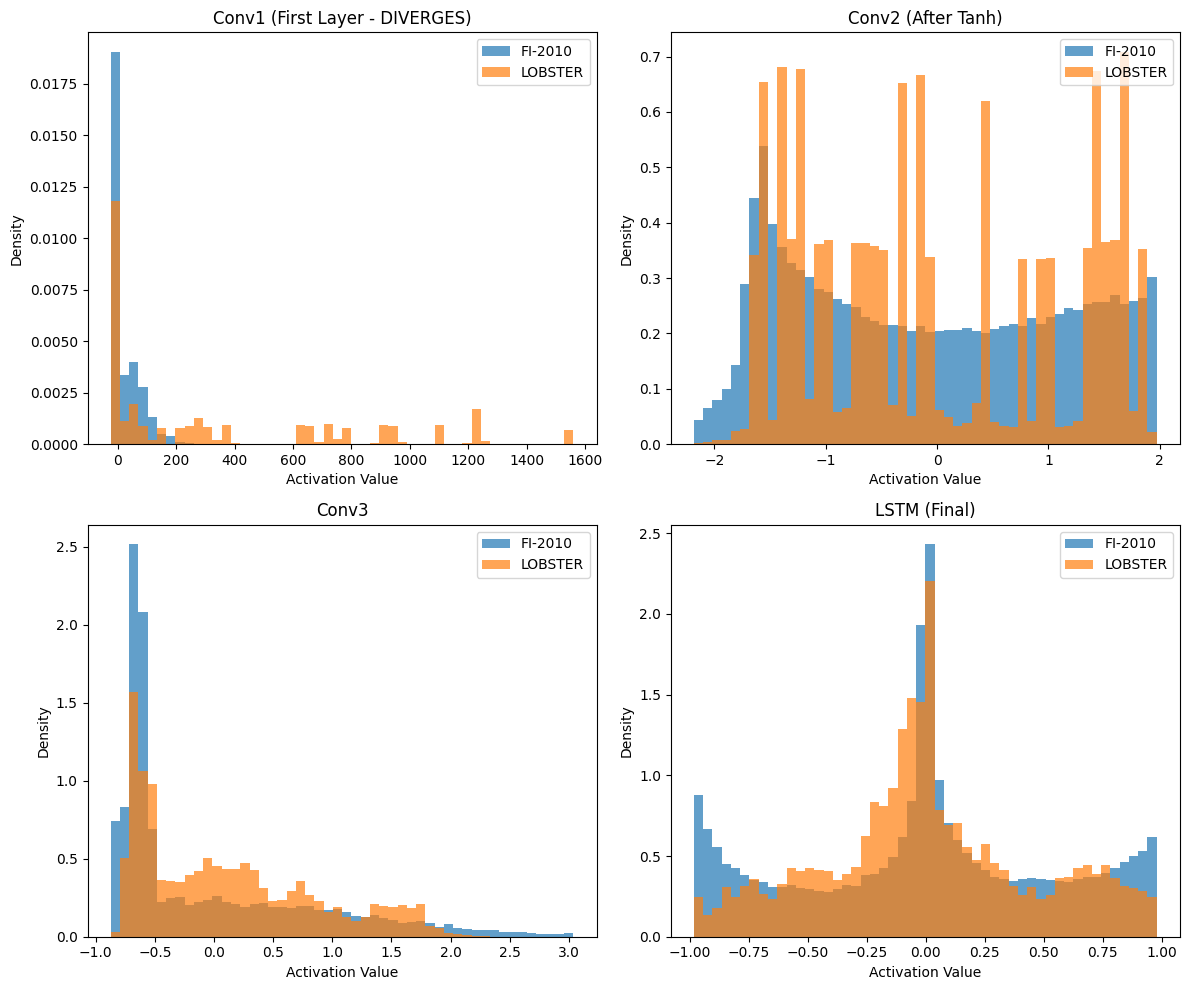

Saved: layer_activations.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

layers = ['conv1', 'conv2', 'conv3', 'lstm']
titles = ['Conv1 (First Layer - DIVERGES)', 'Conv2 (After Tanh)', 'Conv3', 'LSTM (Final)']

for idx, (layer, title) in enumerate(zip(layers, titles)):
    ax = axes[idx // 2, idx % 2]
    
    fi_act = act_fi[layer].cpu().numpy().flatten()
    lob_act = act_lob[layer].cpu().numpy().flatten()
    
    # Use percentiles to handle outliers
    low = min(np.percentile(fi_act, 1), np.percentile(lob_act, 1))
    high = max(np.percentile(fi_act, 99), np.percentile(lob_act, 99))
    
    ax.hist(fi_act, bins=50, alpha=0.7, label='FI-2010', density=True, range=(low, high))
    ax.hist(lob_act, bins=50, alpha=0.7, label='LOBSTER', density=True, range=(low, high))
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('layer_activations.png', dpi=150)
plt.show()

print("Saved: layer_activations.png")